## Section 4

In [1]:
import yfinance as yf
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests
import matplotlib.pyplot as plt

### Parameters

In [2]:
coins = ['BTC-USD', 'ETH-USD', 'USDT-USD', 'XRP-USD', 'SOL-USD', 'BNB-USD', 'DOGE-USD', 'USDC-USD', 'ADA-USD', 'TRX-USD']

start_date = '2023-01-01'
end_date = '2024-01-01'

### Download Data

In [4]:
all_data = {}
for coin in coins:
    data = yf.download(coin, start=start_date, end=end_date, interval='1d')
    all_data[coin] = data['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


### Merge and Store All Data

In [5]:
Index = None
for coin in all_data.keys():
    Index = all_data[coin].index

x = {coin: data.values.flatten() for coin, data in all_data.items()}
all_data_df = pd.DataFrame(x, index=Index)

### Granger Causality

In [19]:
coin_pairs = []

for coin1 in coins:
    for coin2 in coins:
        if coin1 == coin2:
            continue
        coin_pairs.append((coin1, coin2))

grangercausality_res = {}

for coin_pair in coin_pairs:
    coin1, coin2 = coin_pair
    coin_pair_df = pd.DataFrame(columns=[coin1, coin2], data=zip(all_data_df[coin1], all_data_df[coin2]))
    test_result = grangercausalitytests(coin_pair_df, maxlag=10)
    grangercausality_res[coin_pair] = min([test_result[lag][0]['ssr_ftest'][1] for lag in test_result])

top_5_min = sorted(grangercausality_res.items(), key=lambda item: item[1])[:5]

final_top_dependencies = {}
cnt = 0
for item in top_5_min:
    if cnt == 2:
        break
    key, value = item
    coin1, coin2 = key
    if (coin2, coin1) not in final_top_dependencies:
        final_top_dependencies[key] = value
        cnt += 1
    
# print(final_top_dependencies)

# most_dependent_pair = min(grangercausality_res, key=grangercausality_res.get)
# print(most_dependent_pair[0], most_dependent_pair[1])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=12.7201 , p=0.0004  , df_denom=361, df_num=1
ssr based chi2 test:   chi2=12.8258 , p=0.0003  , df=1
likelihood ratio test: chi2=12.6050 , p=0.0004  , df=1
parameter F test:         F=12.7201 , p=0.0004  , df_denom=361, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=6.5568  , p=0.0016  , df_denom=358, df_num=2
ssr based chi2 test:   chi2=13.2968 , p=0.0013  , df=2
likelihood ratio test: chi2=13.0591 , p=0.0015  , df=2
parameter F test:         F=6.5568  , p=0.0016  , df_denom=358, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=4.2190  , p=0.0060  , df_denom=355, df_num=3
ssr based chi2 test:   chi2=12.9065 , p=0.0048  , df=3
likelihood ratio test: chi2=12.6817 , p=0.0054  , df=3
parameter F test:         F=4.2190  , p=0.0060  , df_denom=355, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=3.1624  , p=0.0142  

### Plot Most Dependents

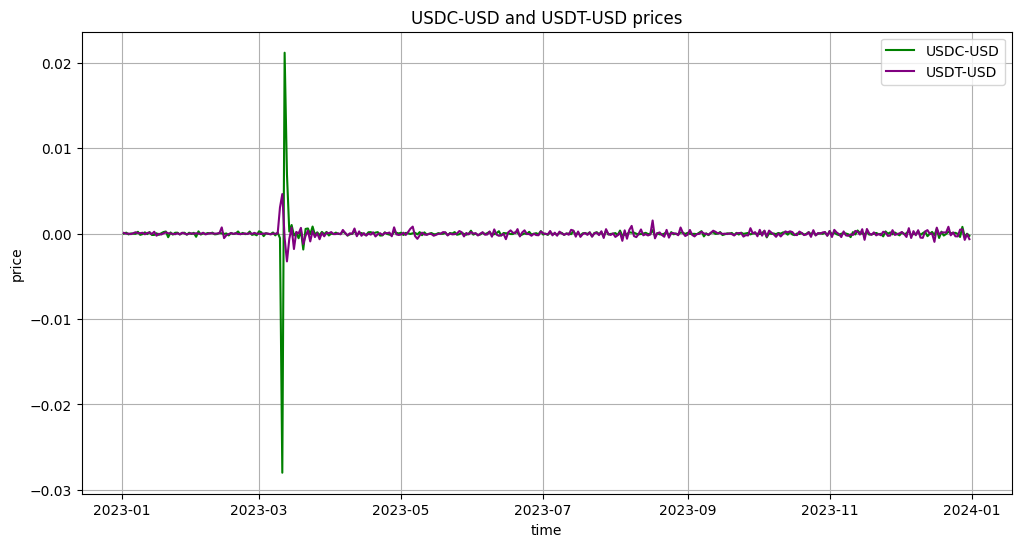

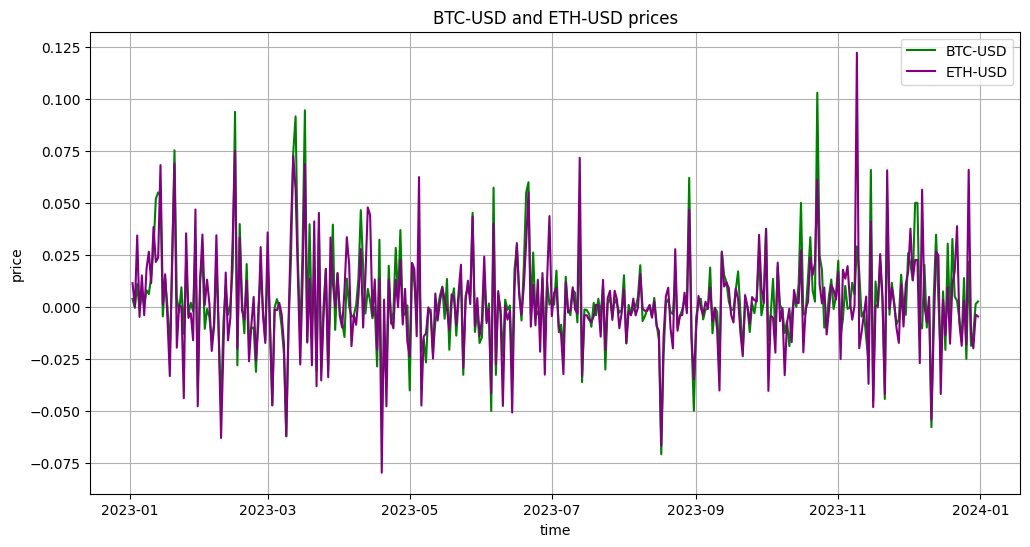

In [26]:
for key, value in final_top_dependencies.items():
    coin1, coin2 = key
    plt.figure(figsize=(12, 6))
    plt.plot(all_data_df.index, all_data_df[coin1].pct_change(), label=coin1, color='green')
    plt.plot(all_data_df.index, all_data_df[coin2].pct_change(), label=coin2, color='purple')
    plt.title(f"{coin1} and {coin2} prices")
    plt.xlabel("time")
    plt.ylabel("price")
    plt.legend()
    plt.grid()
    plt.show()